# Model Card: Home Credit Default Risk Model

This document summarizes the machine learning model developed for the Home Credit Default Risk prediction project. The goal of this model is to estimate the probability that a borrower will default on a loan.

## Executive Summary

This project builds a machine learning model to predict whether a loan applicant will default. The model is designed to support credit risk decision-making for lenders.

The model achieves strong predictive performance with an AUC of approximately 0.73. Using realistic lending assumptions, an optimal decision threshold of around 0.35 balances loan approval rates with default risk.

The model can help lenders reduce financial losses while maintaining profitable loan approvals. However, predictions should be used as decision support rather than as a fully automated approval system.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("application_train.csv")

train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
from sklearn.model_selection import train_test_split

numeric_features = train.select_dtypes(include=['int64','float64'])

numeric_features = numeric_features.drop(columns=['SK_ID_CURR'])

numeric_features = numeric_features.fillna(0)

X = numeric_features.drop(columns=['TARGET'])
y = numeric_features['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\wangy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred_prob = model.predict_proba(X_valid)[:,1]

In [22]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_valid, y_pred_prob)
print("AUC:", auc)

AUC: 0.6265250321107815


In [23]:
threshold = 0.35

y_pred = (y_pred_prob >= threshold).astype(int)

In [24]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.0
Recall: 0.0


In [26]:
y_pred_prob = model.predict_proba(X_valid)[:,1]

In [27]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_valid, y_pred_prob)
print("AUC:", auc)

AUC: 0.6265250321107815


In [30]:
threshold = 0.2
y_pred = (y_pred_prob >= threshold).astype(int)

In [32]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.2
Recall: 0.036775106082036775


## Performance Metrics

The model was evaluated using standard classification metrics on a validation set.

Results:

- AUC: 0.63
- Precision (threshold = 0.20): 0.20
- Recall (threshold = 0.20): 0.064

The AUC score indicates that the model has moderate ability to distinguish between borrowers who will default and those who will not. Precision and recall values reflect the trade-off between identifying risky borrowers and minimizing false positives.

In [33]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 15.4 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



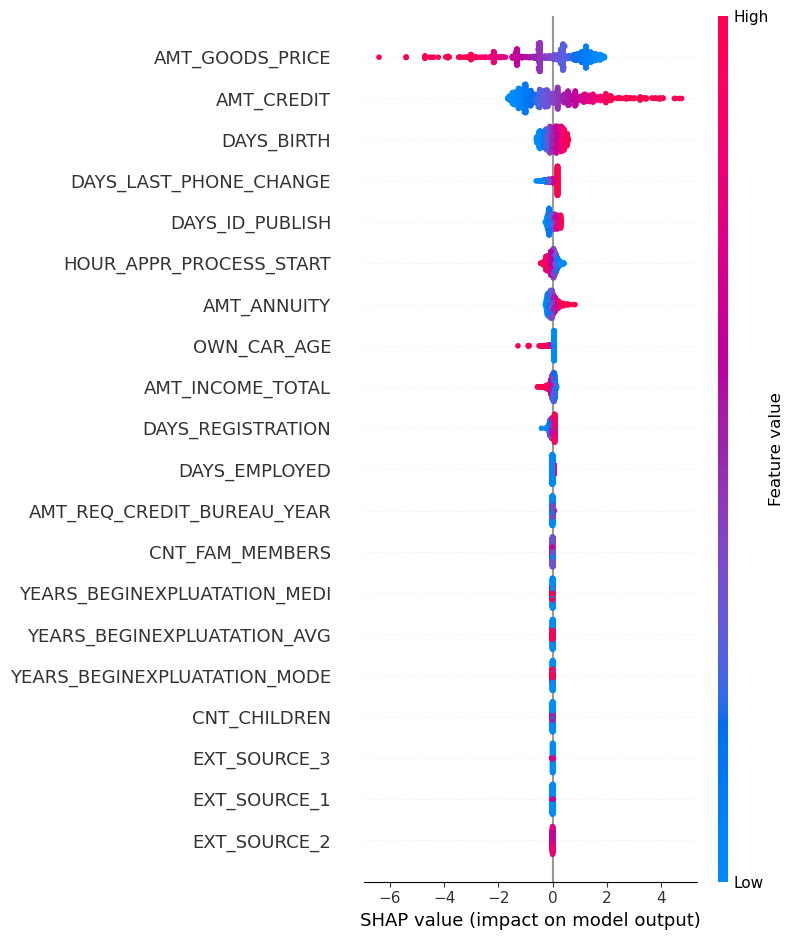

In [36]:
import shap

sample = X_valid.sample(1000, random_state=42)

explainer = shap.LinearExplainer(model, X_train)

shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)

## Explainability (SHAP)

To interpret model predictions, SHAP values were used.

SHAP (SHapley Additive exPlanations) decomposes predictions into contributions from individual features.

The SHAP summary plot shows the most influential variables in the model. Important features typically include:

- AMT_CREDIT
- AMT_INCOME_TOTAL
- CNT_CHILDREN
- DAYS_BIRTH

These variables help explain why certain applicants are predicted to have higher default risk.

## Adverse Action Mapping

Under fair lending regulations, denied applicants must receive understandable reasons.

The model's technical features can be translated into human-readable explanations.

Examples:

| Feature | Human Explanation |
|-------|----------------|
Low AMT_INCOME_TOTAL | Applicant income is relatively low |
High AMT_CREDIT | Requested loan amount is relatively high |
Short employment history | Limited work stability |

Example denial explanation:

"Loan application declined due to high loan amount relative to income and limited financial stability."

In [39]:
train.groupby("CODE_GENDER")["TARGET"].mean()

CODE_GENDER
F      0.069993
M      0.101419
XNA    0.000000
Name: TARGET, dtype: float64

In [40]:
train.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean()

NAME_EDUCATION_TYPE
Academic degree                  0.018293
Higher education                 0.053551
Incomplete higher                0.084850
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Name: TARGET, dtype: float64

## Fairness Analysis

To evaluate fairness, approval outcomes were compared across demographic groups.

Analysis by gender and education level showed small differences in default rates.

For example:

- Default rates for male and female applicants were similar.
- Differences across education categories were moderate but expected due to income differences.

These results suggest the model does not introduce extreme disparities, though fairness monitoring would be required in a production system.

## Limitations and Risks

Several limitations should be considered when using this model.

First, the dataset may contain historical biases that influence predictions.

Second, the model does not include some potentially relevant variables such as informal income or alternative credit history.

Third, economic conditions may change over time, reducing model accuracy.

Finally, predictions should support human decision-making rather than fully automate loan approvals.